In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1) Create noisy signal: 10 Hz sine + 100 Hz sine noise
fs = 1000            # sampling frequency (Hz)
duration = 1.0       # seconds
t = np.arange(0, duration, 1/fs)

signal_10hz = np.sin(2 * np.pi * 10 * t)
noise_100hz = 0.5 * np.sin(2 * np.pi * 100 * t)
noisy_signal = signal_10hz + noise_100hz

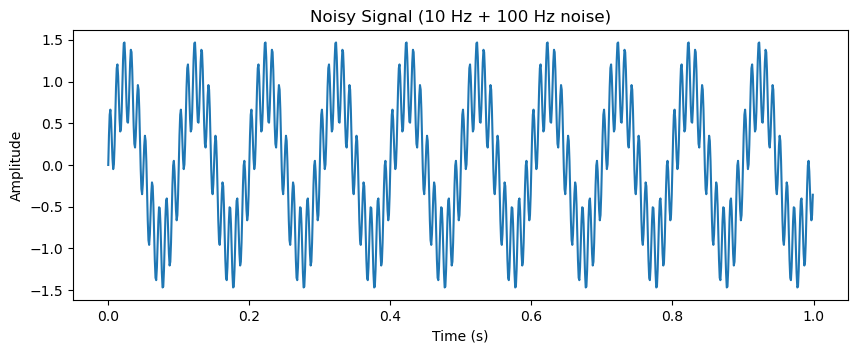

In [5]:
# Show noisy signal
plt.figure(figsize=(10, 3.5))
plt.plot(t, noisy_signal)
plt.title('Noisy Signal (10 Hz + 100 Hz noise)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

In [6]:
# 2) Design low-pass FIR filter (cutoff = 20 Hz) using Hamming window
fc = 20              # cutoff frequency (Hz)
num_taps = 101       # filter length (odd for linear phase)
M = num_taps - 1
n = np.arange(num_taps)

# Ideal low-pass impulse response (windowed-sinc method)
h_ideal = 2 * (fc / fs) * np.sinc(2 * (fc / fs) * (n - M / 2))
window = np.hamming(num_taps)
h = h_ideal * window
h = h / np.sum(h)    # normalize DC gain to 1

In [7]:
# 3) Filter the noisy signal using convolution
filtered_signal = np.convolve(noisy_signal, h, mode='same')

In [ ]:
# 4) Plot noisy and filtered signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy_signal)
plt.title('Noisy Signal')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(t, filtered_signal)
plt.title('Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()